In [92]:
import warnings
import pandas as pd

for warn in [UserWarning, FutureWarning]: warnings.filterwarnings("ignore", category = warn)

import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import numpy as np
import polars as pl
import pandas as pd
import yfinance as yf
import sklearn
import networkx as nx
from sklearn.metrics import mean_squared_error, mean_absolute_error
import ipywidgets
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from torch.utils.data import DataLoader
from sklearn.preprocessing import RobustScaler

from sklearn.preprocessing import MinMaxScaler
from mpl_toolkits.mplot3d import Axes3D
import yfinance as yf

In [93]:
#rsi расчет
def compute_rsi(series, window=14):
    delta = series.diff()
    gain = delta.clip(lower=0)
    loss = (-delta).clip(lower=0)

    avg_gain = gain.rolling(window).mean()
    avg_loss = loss.rolling(window).mean()

    rs = avg_gain / avg_loss
    rsi = 100 - 100 / (1 + rs)
    return rsi

#для тренда
def compute_macd(series, fast=12, slow=26, signal=9):
    ema_fast = series.ewm(span=fast).mean()
    ema_slow = series.ewm(span=slow).mean()

    macd_line = ema_fast - ema_slow
    signal_line = macd_line.ewm(span=signal).mean()

    return macd_line - signal_line

In [94]:
def download_data(ticker="BTC-USD", start_date="2020-01-01", end_date=None):
    if end_date is None:
        end_date = pd.Timestamp.now().strftime('%Y-%m-%d')

    df = yf.download(ticker, start=start_date, end=end_date)

    df = df[['Open', 'High', 'Low', 'Close', 'Volume']]

    df["SMA_7"] = df["Close"].rolling(7).mean()
    df["SMA_30"] = df["Close"].rolling(30).mean()
    df["RSI"] = compute_rsi(df["Close"])
    df["MACD"] = compute_macd(df["Close"])

    df = df.dropna()
    return df


def make_sequences(arr, target_idx, seq_len=60, horizon=30):
    X, y = [], []
    n = len(arr)

    for start in range(n - seq_len - horizon + 1):
        seq_block = arr[start:start + seq_len]
        future_block = arr[start + seq_len : start + seq_len + horizon, target_idx]

        X.append(seq_block)
        y.append(future_block)

    return np.stack(X), np.stack(y)


In [95]:
ticker = "BTC-USD"
data = download_data(ticker)
data.columns = ['_'.join([str(i) for i in col if i != '']).strip() for col in data.columns]

print(data.columns)

close_col = 'Close_BTC-USD'
close_idx = data.columns.get_loc(close_col)


scaler = RobustScaler()
scaled = scaler.fit_transform(data.values)
SEQ_LEN = 60
FORECAST = 30

X, y = make_sequences(scaled, close_idx, seq_len=SEQ_LEN, horizon=FORECAST)
split = int(len(X) * 0.8)

X_train, X_test = np.split(X, [split])
y_train, y_test = np.split(y, [split])


X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32)
X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32)


train_dataset = TensorDataset(X_train_t, y_train_t)
test_dataset = TensorDataset(X_test_t, y_test_t)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

print("Train dataset batches:", len(train_loader))
print("Test dataset batches:", len(test_loader))
print("X_train batch shape:", next(iter(train_loader))[0].shape)
print("y_train batch shape:", next(iter(train_loader))[1].shape)

[*********************100%***********************]  1 of 1 completed

Index(['Open_BTC-USD', 'High_BTC-USD', 'Low_BTC-USD', 'Close_BTC-USD',
       'Volume_BTC-USD', 'SMA_7', 'SMA_30', 'RSI', 'MACD'],
      dtype='object')
Train dataset batches: 26
Test dataset batches: 7
X_train batch shape: torch.Size([64, 60, 9])
y_train batch shape: torch.Size([64, 30])


In [96]:
class RNNmodel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size, dropout=0.2):
        super(RNNmodel, self).__init__()
        self.rnn = nn.RNN(input_size=input_size, hidden_size=hidden_size,
                          num_layers=num_layers, batch_first=True, dropout=dropout)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        out, _ = self.rnn(x)
        out = out[:, -1, :]
        out = self.fc(out)
        return out

class GRUModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size, dropout=0.2):
        super(GRUModel, self).__init__()
        self.gru = nn.GRU(input_size=input_size, hidden_size=hidden_size,
                          num_layers=num_layers, batch_first=True, dropout=dropout)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        out, _ = self.gru(x)
        out = out[:, -1, :]
        out = self.fc(out)
        return out

class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size, dropout=0.2):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(input_size=input_size, hidden_size=hidden_size,
                            num_layers=num_layers, batch_first=True, dropout=dropout)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]
        out = self.fc(out)
        return out

In [97]:
input_size = X_train_t.shape[2]
hidden_size = 64
num_layers = 2
output_size = y_train_t.shape[1]
epochs = 200
lr = 0.001
patience = 35
batch_size = 64

best_loss = float('inf')
no_improve = 0
loss_history = []

In [99]:
def train_model(model, X_train, y_train, criterion, optimizer, epochs=100, patience=35):
    loss_history = []
    best_loss = float('inf')
    no_improve = 0

    for epoch in range(epochs):
        model.train()
        epoch_loss = 0

        for i in range(len(X_train)):
            inputs = X_train[i].unsqueeze(0)
            target = y_train[i]

            optimizer.zero_grad()
            output = model(inputs)
            loss = criterion(output, target)
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()

        avg_loss = epoch_loss / len(X_train)
        loss_history.append(avg_loss)

        if avg_loss < best_loss:
            best_loss = avg_loss
            no_improve = 0
            torch.save(model.state_dict(), f'{model.__class__.__name__}_best.pth')
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f"закончили на {epoch}")
                break

        if epoch % 5 == 0:
            print(f"эпоха {epoch}, лосс: {avg_loss:.6f}")

    return loss_history


In [100]:
def plot(model, X_train, y_train, X_test, y_test, train_losses, title_prefix='Model'):
    plt.figure(figsize=(10,5))
    plt.plot(train_losses, label='Training Loss')
    plt.xlabel('Эпоха')
    plt.ylabel('MSE')
    plt.legend()
    plt.show()

    model.eval()
    with torch.no_grad():
        train_preds = model(X_train).cpu().numpy()
        train_true = y_train.cpu().numpy()

    plt.figure(figsize=(12,6))
    plt.plot(train_true.flatten(), label='Настоящая цена (Train)', color='blue')
    plt.plot(train_preds.flatten(), label='Предсказанная цена (Train)', color='orange')
    plt.xlabel('День')
    plt.legend()
    plt.show()

    with torch.no_grad():
        test_preds = model(X_test).cpu().numpy()
        test_true = y_test.cpu().numpy()

    plt.figure(figsize=(12,6))
    plt.plot(test_true.flatten(), label='Настоящая цена (Test)', color='blue')
    plt.plot(test_preds.flatten(), label='Предсказанная цена (Test)', color='orange')
    plt.xlabel('День')
    plt.legend()
    plt.show()


эпоха 0, лосс: 0.011045
эпоха 5, лосс: 0.051564
эпоха 10, лосс: 0.050376
эпоха 15, лосс: 0.012390
эпоха 20, лосс: 0.027399
эпоха 25, лосс: 0.013259
эпоха 30, лосс: 0.013649
эпоха 35, лосс: 0.011948
закончили на 36


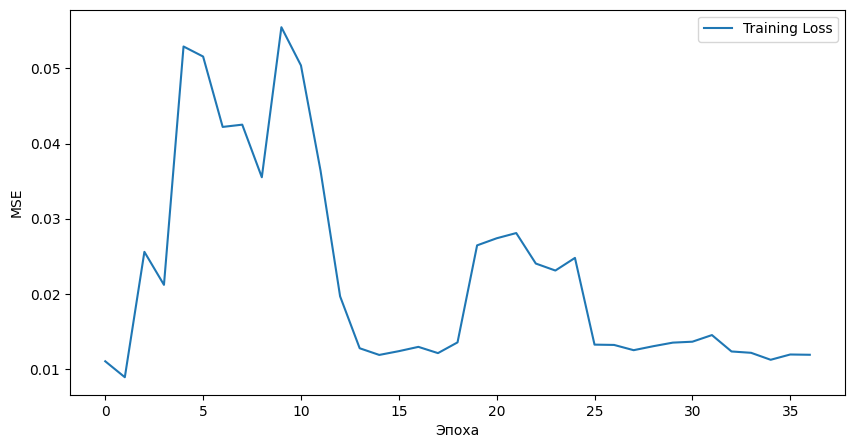

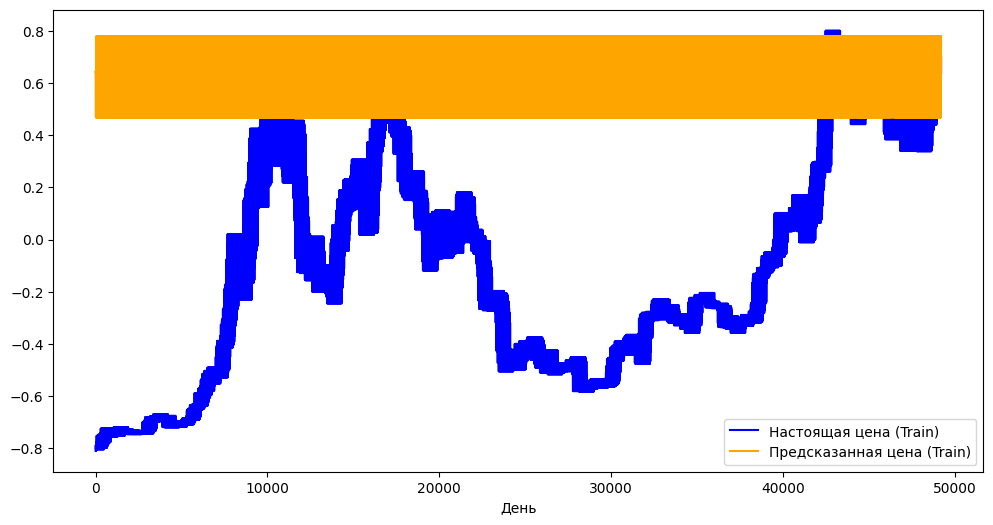

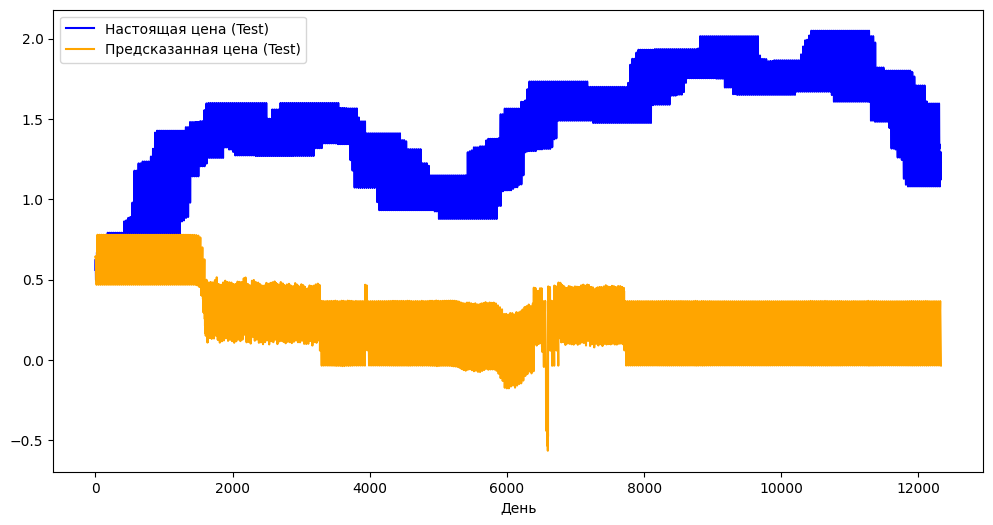

In [103]:
rnn_model = RNNmodel(input_size, hidden_size, num_layers, output_size)
criterion = nn.MSELoss()
optimizer = optim.Adam(rnn_model.parameters(), lr=lr)
train_losses = train_model(rnn_model, X_train_t, y_train_t, criterion, optimizer, epochs=200, patience=35)
plot(rnn_model, X_train_t, y_train_t, X_test_t, y_test_t, train_losses, title_prefix='RNN')

эпоха 0, лосс: 0.010489
эпоха 5, лосс: 0.030713
эпоха 10, лосс: 0.033006
эпоха 15, лосс: 0.029256
эпоха 20, лосс: 0.018853
эпоха 25, лосс: 0.024832
эпоха 30, лосс: 0.022320
закончили на 35


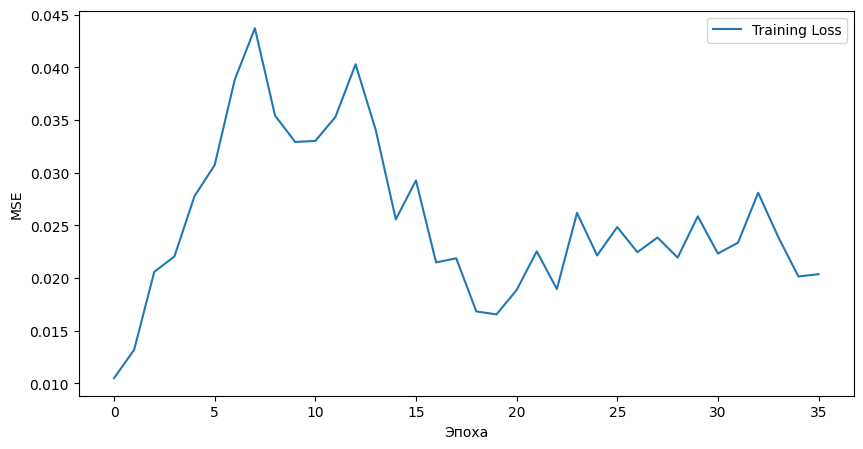

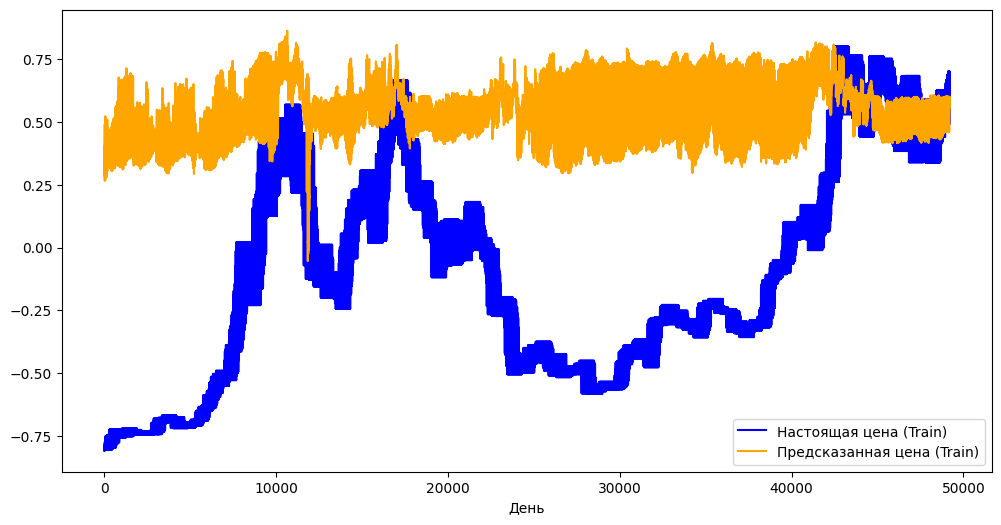

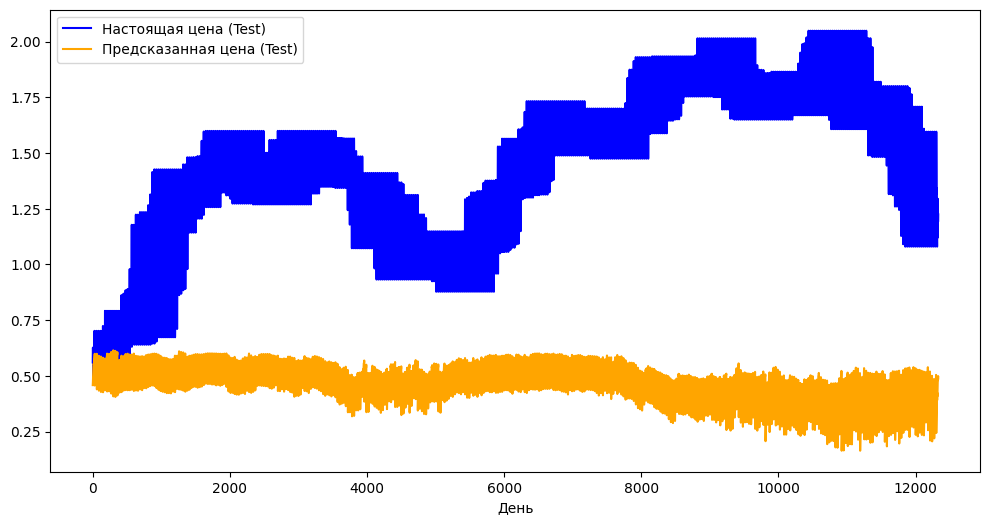

In [104]:
gru_model = GRUModel(input_size, hidden_size, num_layers, output_size)
criterion = nn.MSELoss()
optimizer = optim.Adam(gru_model.parameters(), lr=lr)
train_losses_1 = train_model(gru_model, X_train_t, y_train_t, criterion, optimizer, epochs=200, patience=35)
plot(gru_model, X_train_t, y_train_t, X_test_t, y_test_t, train_losses_1, title_prefix='GRU')

эпоха 0, лосс: 0.011887
эпоха 5, лосс: 0.023938
эпоха 10, лосс: 0.019872
эпоха 15, лосс: 0.030257
эпоха 20, лосс: 0.013016
эпоха 25, лосс: 0.013961
эпоха 30, лосс: 0.012040
эпоха 35, лосс: 0.012139
эпоха 40, лосс: 0.014167
эпоха 45, лосс: 0.012409
эпоха 50, лосс: 0.010414
эпоха 55, лосс: 0.009069
эпоха 60, лосс: 0.007758
эпоха 65, лосс: 0.008242
эпоха 70, лосс: 0.005804
эпоха 75, лосс: 0.004757
эпоха 80, лосс: 0.004636
эпоха 85, лосс: 0.003583
эпоха 90, лосс: 0.003432
эпоха 95, лосс: 0.002800
эпоха 100, лосс: 0.002595
эпоха 105, лосс: 0.002535
эпоха 110, лосс: 0.002122
эпоха 115, лосс: 0.002392
эпоха 120, лосс: 0.002143
эпоха 125, лосс: 0.002024
эпоха 130, лосс: 0.002371
эпоха 135, лосс: 0.001884
эпоха 140, лосс: 0.002077
эпоха 145, лосс: 0.002047
эпоха 150, лосс: 0.001992
эпоха 155, лосс: 0.001730
эпоха 160, лосс: 0.002333
эпоха 165, лосс: 0.001729
эпоха 170, лосс: 0.001746
эпоха 175, лосс: 0.001788
эпоха 180, лосс: 0.001696
эпоха 185, лосс: 0.001549
эпоха 190, лосс: 0.001701
эпоха 19

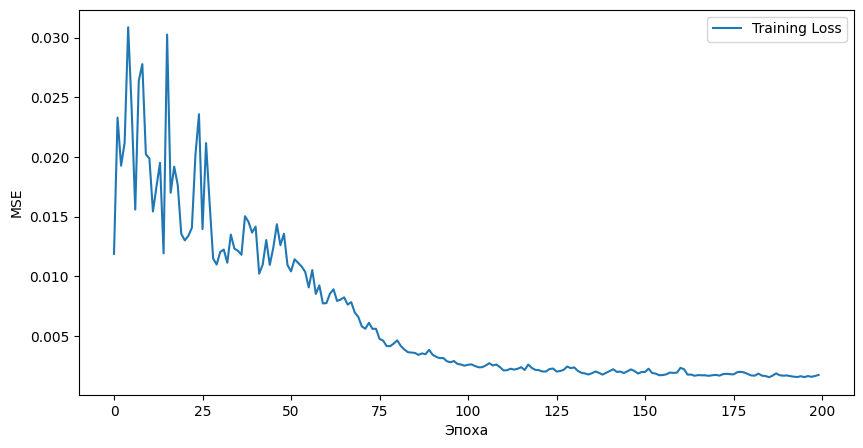

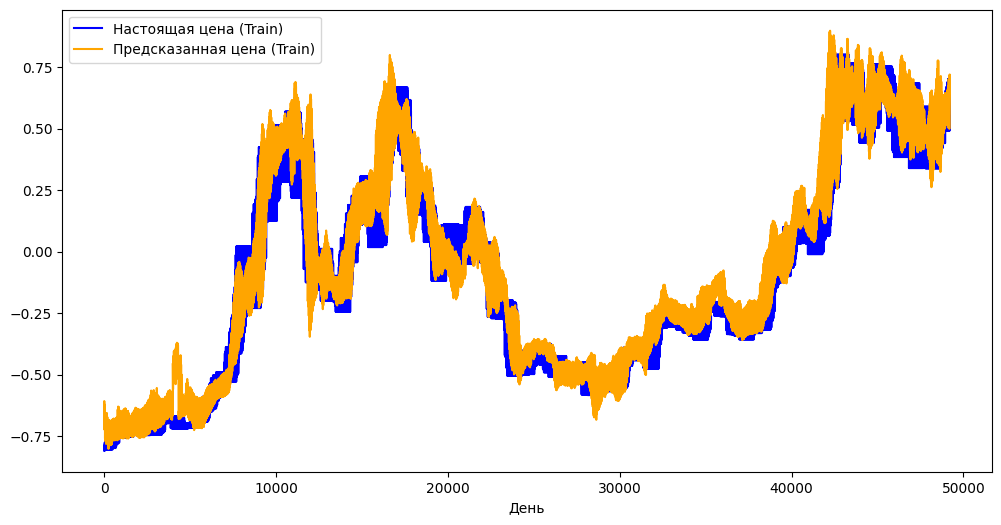

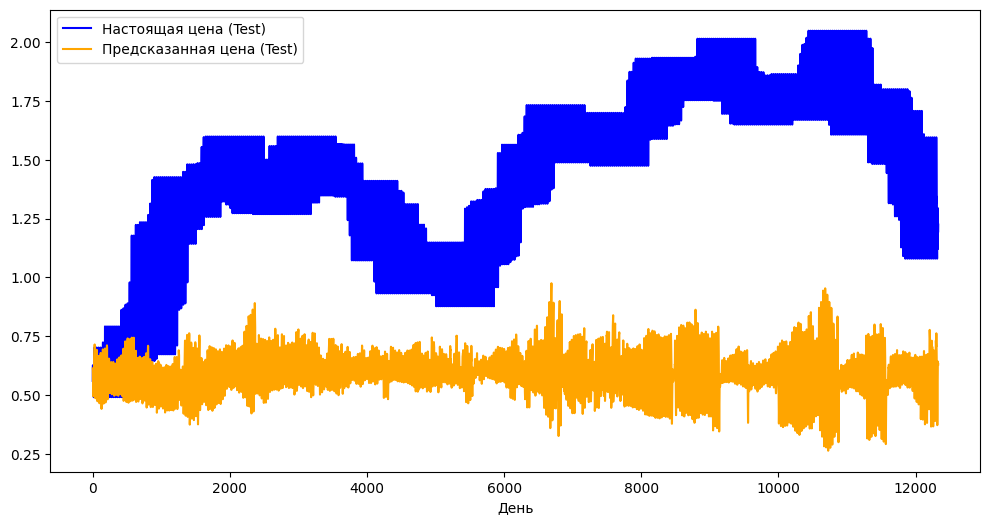

In [105]:
lstm_model = LSTMModel(input_size, hidden_size, num_layers, output_size)
criterion = nn.MSELoss()
optimizer = optim.Adam(lstm_model.parameters(), lr=lr)
train_losses_2 = train_model(lstm_model, X_train_t, y_train_t, criterion, optimizer, epochs=200, patience=35)
plot(lstm_model, X_train_t, y_train_t, X_test_t, y_test_t, train_losses_2, title_prefix='LSTM')

In [108]:
rnn_model.load_state_dict(torch.load('RNNmodel_best.pth'))
gru_model.load_state_dict(torch.load('GRUModel_best.pth'))
lstm_model.load_state_dict(torch.load('LSTMModel_best.pth'))

<All keys matched successfully>

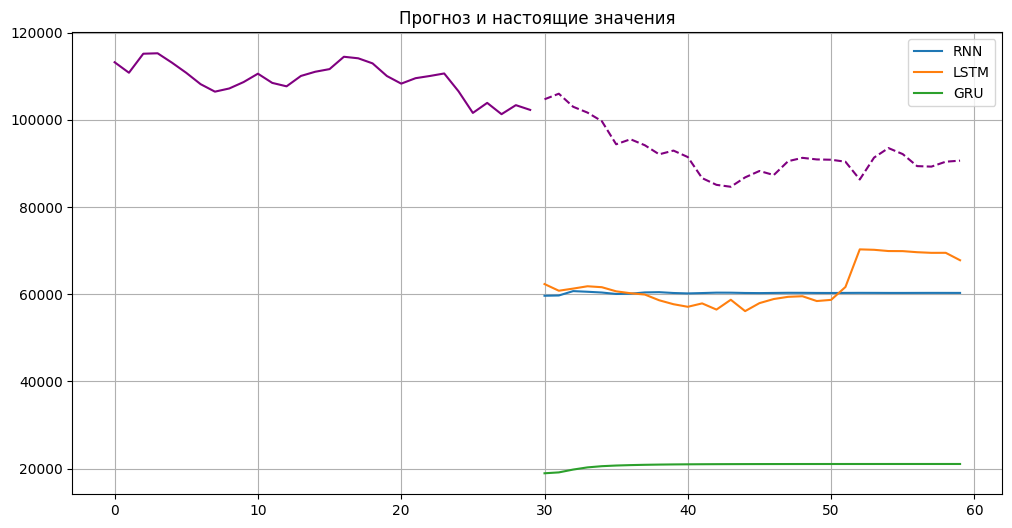

In [115]:
def forecast(model, seq, scaler, close_idx, seq_length=60, n_days=30, device='cpu'):
    model.eval()
    model.to(device)
    current_seq = seq.copy()
    predictions_scaled = []

    with torch.no_grad():
        for _ in range(n_days):
            x = torch.FloatTensor(current_seq).unsqueeze(0).to(device)
            pred = model(x)
            pred = pred.squeeze(0).cpu().numpy()
            next_pred = pred[0]
            next_row = current_seq[-1].copy()
            next_row[close_idx] = next_pred
            current_seq = np.vstack([current_seq[1:], next_row])
            predictions_scaled.append(next_pred)

    dummy = np.zeros((n_days, seq.shape[1]))
    predictions_scaled = np.array(predictions_scaled).flatten()
    dummy[:, close_idx] = predictions_scaled
    predictions_unscaled = scaler.inverse_transform(dummy)[:, close_idx]
    return predictions_unscaled


initial_seq = scaled[-60:]

preds_rnn = forecast(rnn_model, initial_seq, scaler, close_idx, seq_length=60, n_days=30)
preds_lstm = forecast(lstm_model, initial_seq, scaler, close_idx, seq_length=60, n_days=30)
preds_gru = forecast(gru_model, initial_seq, scaler, close_idx, seq_length=60, n_days=30)

true_values = data['Close_BTC-USD'].values[-60:]

plt.figure(figsize=(12,6))
plt.plot(range(30), true_values[:30],color='purple')
plt.plot(range(30, 60), true_values[30:], color='purple', linestyle='--')
plt.plot(range(30, 60), preds_rnn, label='RNN')
plt.plot(range(30, 60), preds_lstm, label='LSTM')
plt.plot(range(30, 60), preds_gru, label='GRU')
plt.title('Прогноз и настоящие значения')
plt.legend()
plt.grid(True)
plt.show()


Сравнение моделей по метрикам MSE и MAE:
  Model           MSE           MAE
0   RNN  1.061616e+09  32104.894731
1  LSTM  9.696826e+08  30294.995212
2   GRU  5.160741e+09  71589.630084


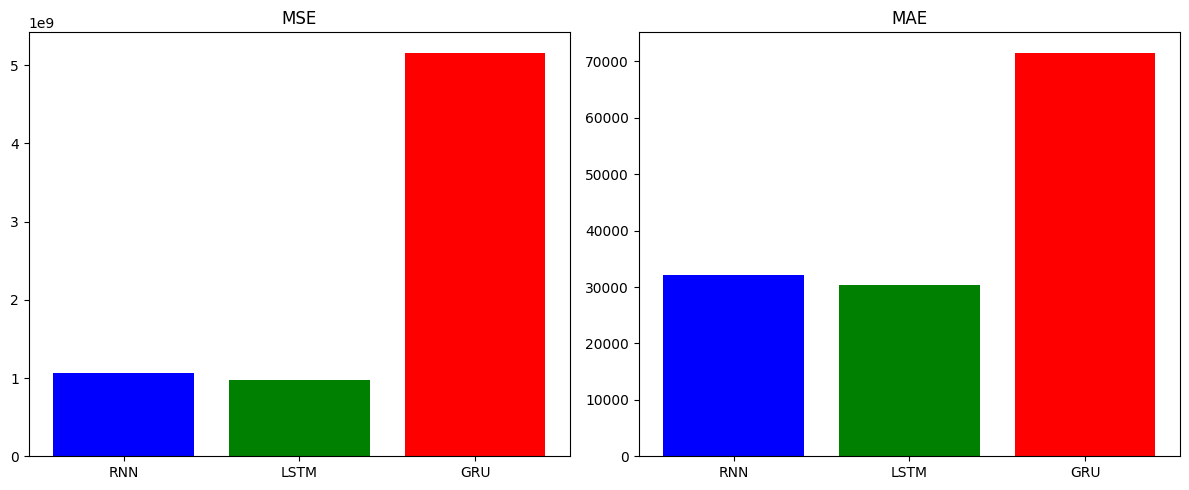

In [114]:
def compute_metrics(true_values, preds, name='Model'):
    mse = mean_squared_error(true_values, preds)
    mae = mean_absolute_error(true_values, preds)
    return mse, mae


true_30 = data['Close_BTC-USD'].values[-30:]
rnn_mse, rnn_mae = compute_metrics(true_30, preds_rnn, 'RNN')
lstm_mse, lstm_mae = compute_metrics(true_30, preds_lstm, 'LSTM')
gru_mse, gru_mae = compute_metrics(true_30, preds_gru, 'GRU')

metrics = {
    'Model': ['RNN', 'LSTM', 'GRU'],
    'MSE': [rnn_mse, lstm_mse, gru_mse],
    'MAE': [rnn_mae, lstm_mae, gru_mae]
}

metrics_df = pd.DataFrame(metrics)
print("Сравнение моделей по метрикам MSE и MAE:")
print(metrics_df)


plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.bar(metrics_df['Model'], metrics_df['MSE'], color=['blue', 'green', 'red'])
plt.title('MSE')

plt.subplot(1, 2, 2)
plt.bar(metrics_df['Model'], metrics_df['MAE'], color=['blue', 'green', 'red'])
plt.title('MAE')

plt.tight_layout()
plt.show()


1. Добавление признаков помогает выявить больше закономерностей, так что я рассматривала данные с признаками ['Open', 'High', 'Low', 'Close', 'Volume']

2. В ноутбуке использовался minmax scaler, однако в наших данных(криптовалюта) достаточно нередко явление выбросов. Поэтому лучше использовать robust scaler(там используется медиана и перцентили)


3. в train_model добавила остановка, чтобы не крутились все шаги, когда
это уже не дает нужного результата.

4. по метрикам получилось rnn и lstm похожи, а вот с gru проблемы, видимо надо лучше подбирать параметры)